In [ ]:
# pip install sklearn-pandas

In [21]:
# replicating_automl_model.py

# ============================================
# Traffic Volume Prediction (Classification)
# ============================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# --------------------------------------------
# Load and Prepare Data
# --------------------------------------------
df = pd.read_csv("data/output/Traffic_Facility_Clustered_For_Classification.csv")

# Convert DATE column to datetime
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# Optional: Extract useful date features
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month
df["Day"] = df["DATE"].dt.day
df["DayOfWeek"] = df["DATE"].dt.dayofweek

# Drop original DATE after feature extraction
df = df.drop(columns=["DATE"])

# Define target and features
X = df.drop(columns=["Volume_Level"])
y = df["Volume_Level"]

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# --------------------------------------------
# Define Preprocessing
# --------------------------------------------

# Categorical and numerical columns
categorical_features = ["FAC"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# Column transformer: scale numeric, one-hot encode categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# --------------------------------------------
# Build Pipeline
# --------------------------------------------
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=10
    ))
])

# --------------------------------------------
# Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# --------------------------------------------
# Train Model
# --------------------------------------------
pipeline.fit(X_train, y_train)

# --------------------------------------------
# Evaluate
# --------------------------------------------
y_pred = pipeline.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# --------------------------------------------
# Predict on New Data (Example)
# --------------------------------------------
sample = X_test.iloc[:1]
pred_label = label_encoder.inverse_transform(pipeline.predict(sample))
print("\nSample prediction for first row in X_test:", pred_label[0])

# --------------------------------------------
# Save Model (Optional)
# --------------------------------------------
import joblib
joblib.dump(pipeline, "traffic_volume_model.pkl")
joblib.dump(label_encoder, "volume_label_encoder.pkl")

print("\nModel training completed and saved successfully.")




Accuracy: 0.995

Classification Report:
               precision    recall  f1-score   support

        High       1.00      1.00      1.00      4384
         Low       1.00      0.98      0.99       919
      Medium       0.99      0.99      0.99      3489

    accuracy                           0.99      8792
   macro avg       1.00      0.99      0.99      8792
weighted avg       1.00      0.99      0.99      8792


Sample prediction for first row in X_test: Medium

✅ Model training completed and saved successfully.


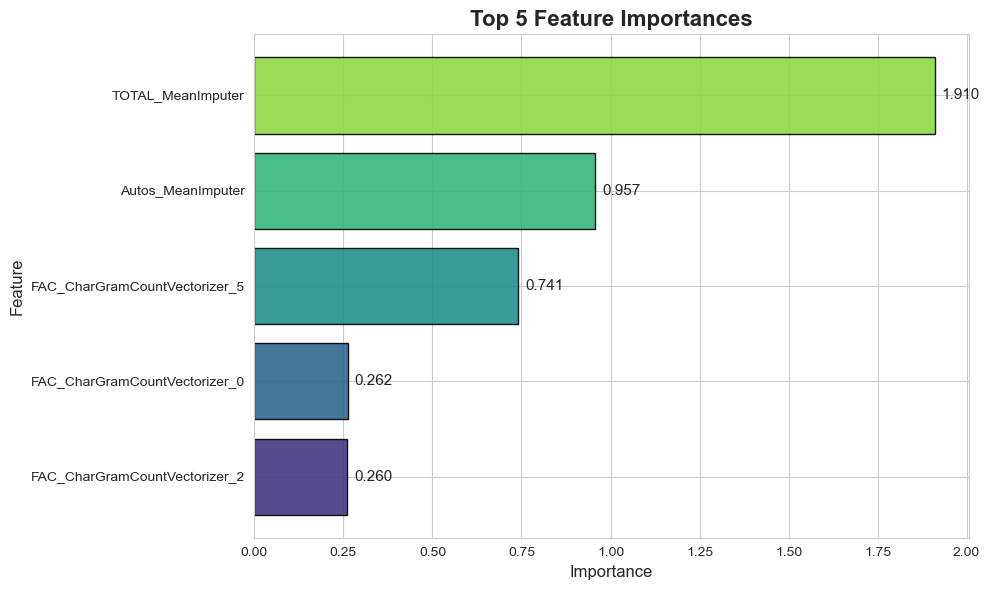

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# Feature names
# -------------------------------
features = [
    "TOTAL_MeanImputer",
    "Autos_MeanImputer",
    "FAC_CharGramCountVectorizer_5",
    "FAC_CharGramCountVectorizer_0",
    "FAC_CharGramCountVectorizer_2",
    "FAC_CharGramCountVectorizer_7",
    "FAC_CharGramCountVectorizer_6",
    "Small_T_MeanImputer",
    "FAC_CharGramCountVectorizer_4",
    "FAC_CharGramCountVectorizer_3",
    "Large_T_MeanImputer",
    "VIOLATION_MeanImputer",
    "Buses_MeanImputer",
    "FAC_CharGramCountVectorizer_1",
    "DATE_ModeCatImputer_Day",
    "DATE_ModeCatImputer_DayOfYear",
    "DATE_ModeCatImputer_Year",
    "DATE_ModeCatImputer_DayOfWeek",
    "DATE_ModeCatImputer_Month",
    "DATE_ModeCatImputer_WeekOfMonth",
    "DATE_ModeCatImputer_Second",
    "DATE_ModeCatImputer_Minute",
    "DATE_ModeCatImputer_Hour",
    "DATE_ModeCatImputer_QuarterOfYear"
]

# -------------------------------
# Importance values
# -------------------------------
importance_values = [
    1.9100585382902004,
    0.9570559622380959,
    0.7411633539905988,
    0.2620482295791087,
    0.2600774589376064,
    0.2538450317433967,
    0.215229560120771,
    0.21243247734600282,
    0.1764133119108858,
    0.16603428233443854,
    0.13059573586546447,
    0.13039160575841316,
    0.11700810211175695,
    0.1138170697298579,
    0.07535257228863189,
    0.07147238734313639,
    0.036008569835726784,
    0.025602508051362164,
    0.012800246300785705,
    0.0005822452077229092,
    0, 0, 0, 0
]

# -------------------------------
# Create DataFrame
# -------------------------------
df = pd.DataFrame({
    "Feature": features,
    "Importance": importance_values
})

# -------------------------------
# Select Top 5 Features
# -------------------------------
top5 = df.sort_values(by="Importance", ascending=False).head(5)

# -------------------------------
# Plot horizontal bar chart
# -------------------------------
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("viridis", len(top5))[::-1]
bars = plt.barh(top5["Feature"], top5["Importance"], color=colors, edgecolor='k', alpha=0.9)

# Annotate values
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center', fontsize=11)

plt.title("Top 5 Feature Importances", fontsize=16, weight='bold')
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
